# Time Series Analysis - Machine Learning Methods

This notebook applies **tree-based** and **deep learning** models to time series forecasting and anomaly detection as the next step after classical statistical methods.

**Methods covered:**
1. **Random Forest**: Ensemble ML applied to TS via lag features; underfitting vs. overfitting comparison
2. **Isolation Forest**: Unsupervised tree-based anomaly detection
3. **RNN**: Recurrent Neural Network that processes sequences step-by-step via a hidden state
4. **TCN**: Temporal Convolutional Network using dilated causal convolutions

**Key difference from traditional methods:** these models learn feature representations from data directly without explicit decomposition, stationarity requirement, or manual order selection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from darts import TimeSeries
import optuna

import warnings
warnings.filterwarnings("ignore")

## Load Data

In [40]:
df = pd.read_csv("data/dwd_02932_climate.csv", sep=";", parse_dates=["date"], index_col="date")[["temperature_air_mean_2m", "precipitation_height"]]
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 18263 entries, 1975-01-01 to 2024-12-31
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   temperature_air_mean_2m  18263 non-null  float64
 1   precipitation_height     18263 non-null  float64
dtypes: float64(2)
memory usage: 428.0 KB


In [47]:
df_w = df.resample("W").mean()
df_w.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2610 entries, 1975-01-05 to 2025-01-05
Freq: W-SUN
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   temperature_air_mean_2m  2610 non-null   float64
 1   precipitation_height     2610 non-null   float64
dtypes: float64(2)
memory usage: 61.2 KB


In [48]:
df_w_temp_train = df_w['temperature_air_mean_2m'].loc[:'2022']
print(df_w_temp_train.tail())

date
2022-11-27    3.614286
2022-12-04    1.714286
2022-12-11    0.600000
2022-12-18   -6.414286
2022-12-25    6.400000
Freq: W-SUN, Name: temperature_air_mean_2m, dtype: float64


## 1. Data & Setup

Same dataset and split as for the traditional methods:
- **Training:** 1975–2022 (~2500 weekly observations)
- **Test (forecast horizon):** 2023–2024 (104 weeks)

For the neural network section an **additional inner split** is used during hyperparameter optimisation (HPO):
- HPO train: 1975–2020
- HPO validation: 2021–2022

> The test set (2023–2024) is never seen during HPO and only used at the final evaluation.

## 2. Random Forest for Time Series

Standard Random Forest is a **tabular model**, it has no inherent notion of time. The darts library bridges this by converting the series into a supervised learning problem via **lag features**:

- `lags=52`: uses the past 52 weekly values as input features, the model sees one full year of history
- `output_chunk_length=6`: predicts 6 steps simultaneously, `predict(104)` applies this iteratively
- Two models are compared with deliberately extreme configurations to illustrate the bias-variance trade-off:
  - **Small (2 estimators, depth 2):** high bias, low variance - underfits, produces a smooth flat forecast
  - **Large (200 estimators, depth 20):** low bias, high variance - can overfit the training window

> **Pitfalls:**  
> _No extrapolation_: Random Forests cannot predict values outside the range seen during training.  
> For a series with a stable range (temperature) this is acceptable.  
> For a trending series, the forecast will plateau and diverge from reality.

In [4]:
from darts.models import RandomForestModel

# Create training data as TimeSeries
temp_series_train = TimeSeries.from_series(df_w_temp_train)

In [5]:
est_small = 2
depth_small = 2

model_small = RandomForestModel(
    lags=52,
    output_chunk_length=6,
    n_estimators=est_small,
    max_depth=depth_small,
)
model_small.fit(temp_series_train)

RandomForestModel(lags=52, lags_past_covariates=None, lags_future_covariates=None, output_chunk_length=6, output_chunk_shift=0, add_encoders=None, n_estimators=2, max_depth=2, multi_models=True, use_static_covariates=True, random_state=None)

In [6]:
est_big = 200
depth_big = 20

model_big = RandomForestModel(
    lags=52,
    output_chunk_length=6,
    n_estimators=est_big,
    max_depth=depth_big,
)
model_big.fit(temp_series_train)

RandomForestModel(lags=52, lags_past_covariates=None, lags_future_covariates=None, output_chunk_length=6, output_chunk_shift=0, add_encoders=None, n_estimators=200, max_depth=20, multi_models=True, use_static_covariates=True, random_state=None)

### Backtesting with `historical_forecasts`

`historical_forecasts` simulates what the already-fitted model *would have predicted* at each past point in time as a form of **in-sample backtesting**:

- `retrain=False`: uses the single fitted model (no walk-forward retraining)
- `forecast_horizon=6`: each backtest step forecasts 6 weeks ahead

The backtest curves (plotted in light colour) show in-sample forecast quality and help visualise where the model tracks the signal well vs. where it lags.

> **Pitfall:**  
> With `retrain=False` the model was trained on the *full* training series.  
> Backtest results are optimistic compared to a true walk-forward evaluation where the model would be retrained on only the data available at each point in time.

In [7]:
pred_small = model_small.predict(104)
pred_big = model_big.predict(104)
fitted_small = model_small.historical_forecasts(temp_series_train, forecast_horizon=6, retrain=False)
fitted_big = model_big.historical_forecasts(temp_series_train, forecast_horizon=6, retrain=False)

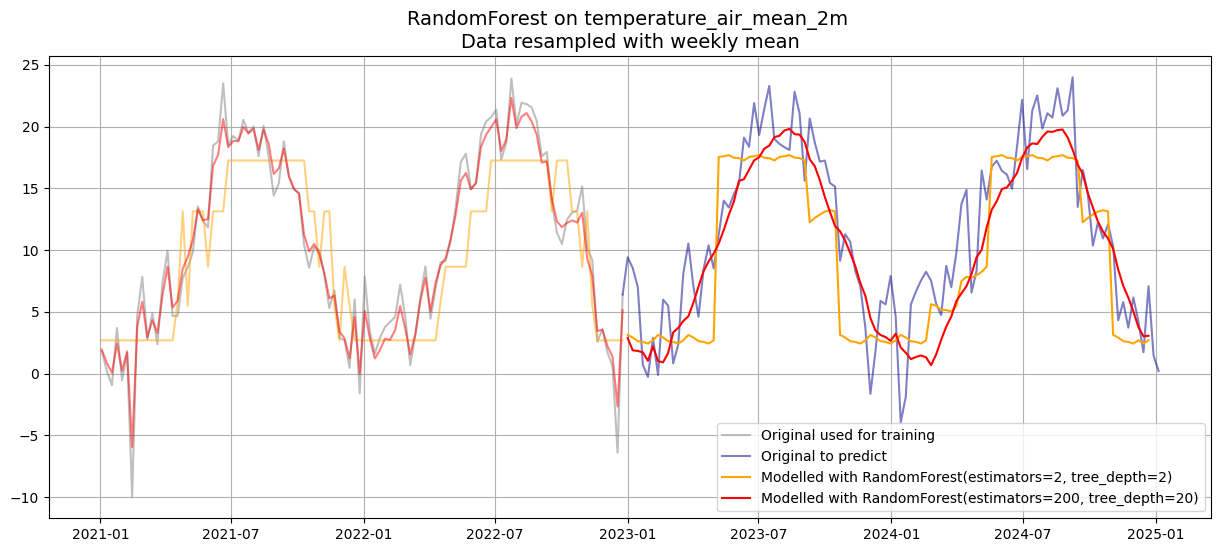

In [8]:
plt.figure(figsize=(15, 6))
plt.plot(df_w_temp.loc["2021":"2022"], label='Original used for training', color='grey', alpha=0.5)
plt.plot(df_w_temp.loc["2022-12-25":], label='Original to predict', color='darkblue', alpha=0.5)
plt.plot(pred_small.to_series(), label=f'Modelled with RandomForest(estimators={est_small}, tree_depth={depth_small})', color='orange')
plt.plot(pred_big.to_series(), label=f'Modelled with RandomForest(estimators={est_big}, tree_depth={depth_big})', color='red')
plt.plot(fitted_small.to_series().loc["2021":], color='orange', alpha=0.5)
plt.plot(fitted_big.to_series().loc["2021":], color='red', alpha=0.5)
plt.title(f"RandomForest on {df_w_temp.name} \nData resampled with weekly mean", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

### Isolation Forest for Anomaly Detection

`IsolationForest` detects anomalies by building an ensemble of **random trees that isolate each data point**.  
Points requiring fewer splits to isolate (shorter average path length) are more anomalous.

Key parameters:
- `n_estimators`: number of isolation trees, more trees give more stable anomaly scores
- `contamination`: *expected* fraction of anomalies, a strong prior that sets the decision threshold

> **Pitfalls**  
> _Raw seasonal data:_ Applied to the raw precipitation series, seasonal peaks are genuinely extreme values and may be flagged as anomalies. Applying isolation forest to STL residuals (as done with Z-Score in notebook 02) separates structural seasonality from true outliers.  
> _Contamination is a tuning parameter:_ Setting `contamination=0.02` means exactly 2% of points are always flagged, regardless of whether that reflects the actual anomaly rate.

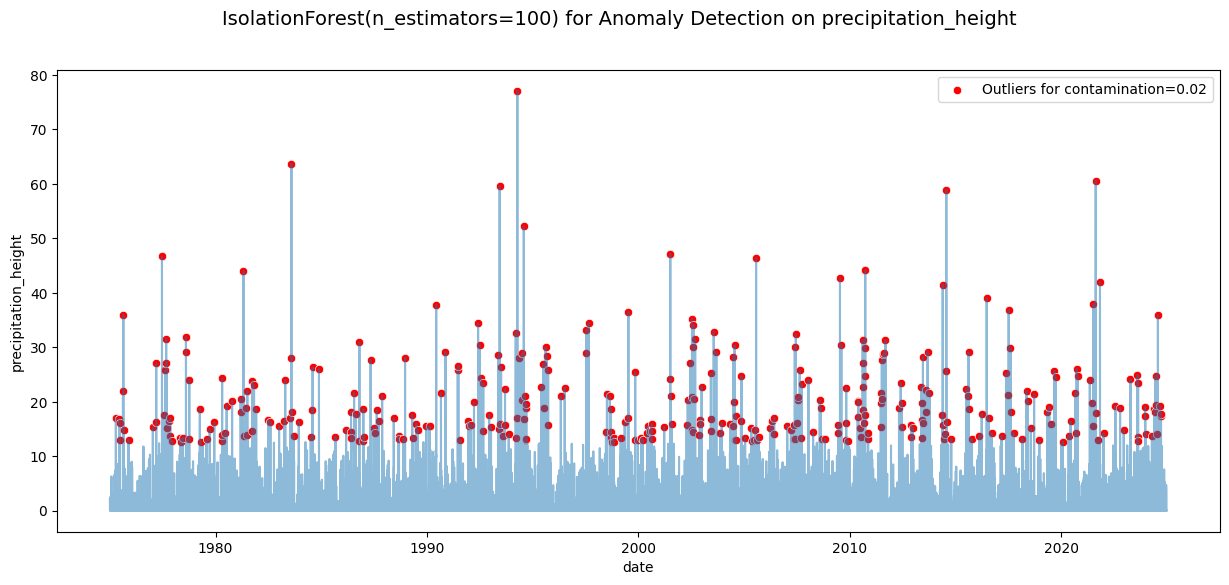

In [42]:
from sklearn.ensemble import IsolationForest

df_prec = df[['precipitation_height']].copy()

n_estimators = 100
contamination = 0.02

model = IsolationForest(n_estimators=n_estimators, contamination=contamination, random_state=42)
model.fit(df_prec)

df_prec['outliers'] = model.predict(df_prec)
df_prec['outliers'] = df_prec['outliers'].apply(lambda x: True if x == -1 else False)

# Plot timeseries with marked outliers
fig, ax = plt.subplots(figsize=(15, 6))
sns.lineplot(data=df_prec, x=df_prec.index, y='precipitation_height', alpha=0.5, ax=ax)
sns.scatterplot(x=df_prec.index[df_prec['outliers']], y=df_prec['precipitation_height'][df_prec['outliers']], 
                color='red', label=f'Outliers for contamination={contamination}', ax=ax)
plt.suptitle(f'IsolationForest(n_estimators={n_estimators}) for Anomaly Detection on precipitation_height', fontsize=14)
plt.show()

## Recurrent Neural Network (RNN)

An RNN processes a sequence **one step at a time**, updating a **hidden state** that carries information forward through time.

Key hyperparameters searched by [Optuna](https://optuna.org/):

- `hidden_dim`: Size of the hidden state, controls expressiveness
- `n_rnn_layers`: Stacked depth
- `input_chunk_length`: Past steps fed as context
- `training_length`: Total sequence length per training sample
- `dropout`: Regularisation, randomly zeros neurons each step
- `lr`: Learning rate for Adam optimiser

> **Pitfalls**  
> _Vanishing gradients:_ Vanilla RNNs struggle to retain information across many steps. Gradients shrink exponentially through backpropagation-through-time, making long-range dependencies (e.g. last year's seasonal pattern) hard to learn. For long memory requirements, TCN or LSTM are more reliable.

In [10]:
from darts.dataprocessing.transformers import Scaler
from darts.metrics import rmse, mape

# Create training data as TimeSeries
series = TimeSeries.from_series(df_w_temp.loc[:"2022"])
series = series.astype(np.float32)

# Create training and validation sets:
train, val = series.split_after(pd.Timestamp("2020"))

# Normalize the time series (note: we avoid fitting the transformer on the validation set)
transformer = Scaler()
train_transformed = transformer.fit_transform(train)
val_transformed = transformer.transform(val)

In [11]:
from darts.models import RNNModel

def objective_rnn(trial):
    n_rnn_layers = trial.suggest_int('n_rnn_layers', 1, 3)
    hidden_dim = trial.suggest_categorical('hidden_dim', [16, 32, 64, 128])
    dropout = trial.suggest_float('dropout', 0.0, 0.5)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    n_epochs = trial.suggest_int('n_epochs', 10, 50, step=5)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    input_chunk_length = trial.suggest_int('input_chunk_length', 5, 30)
    training_length = trial.suggest_int('training_length', input_chunk_length, input_chunk_length + 10)

    model = RNNModel(
        model="RNN",
        n_rnn_layers=n_rnn_layers,
        hidden_dim=hidden_dim,
        dropout=dropout,
        batch_size=batch_size,
        n_epochs=n_epochs,
        optimizer_kwargs={"lr": lr},
        model_name="Temp_RNN",
        log_tensorboard=True,
        random_state=42,
        training_length=training_length,
        input_chunk_length=input_chunk_length,
        force_reset=True,
        pl_trainer_kwargs={"accelerator": "auto", "devices": 1},
    )
    model.fit(train_transformed, val_series=val_transformed, verbose=False)
    pred = model.predict(len(val_transformed))

    # Evaluate on original scale (inverse-transform before computing metrics)
    pred_orig = transformer.inverse_transform(pred)
    val_orig  = transformer.inverse_transform(val_transformed)
    return rmse(val_orig, pred_orig), mape(val_orig, pred_orig)

## Temporal Convolutional Network (TCN)

TCN uses **dilated causal convolutions**, filters that only look at past positions (causal) with exponentially increasing gaps (dilation), giving a large receptive field without deep stacks of parameters.

Key hyperparameters searched by [Optuna](https://optuna.org/):

- `kernel_size`: Time steps each filter spans
- `dilation_base`: Dilation multiplier per layer
- `num_layers`: Depth, receptive field ≈ `(kernel_size−1) × (dilation_base^num_layers − 1) + 1`
- `num_filters`: Parallel filters per layer, controls width
- `output_chunk_length`: Future steps predicted in one forward pass

> **Pitfalls**  
> _Receptive field vs. seasonal period:_ The receptive field must cover at least one full seasonal cycle (52 weeks here). With small `kernel_size` and `dilation_base`, the model may not "see" far enough back to capture annual patterns and will produce near-flat forecasts.

In [12]:
from darts.models import TCNModel

def objective_tcn(trial):
    input_chunk_length = trial.suggest_int('input_chunk_length', 10, 30)
    output_chunk_length = trial.suggest_int('output_chunk_length', 1, 9)
    kernel_size = trial.suggest_int('kernel_size', 2, 5)
    num_filters = trial.suggest_int('num_filters', 2, 5)
    num_layers = trial.suggest_int('num_layers', 1, 3)
    dilation_base = trial.suggest_int('dilation_base', 1, 3)
    dropout = trial.suggest_float('dropout', 0.0, 0.5)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    n_epochs = trial.suggest_int('n_epochs', 10, 100, step=5)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

    model = TCNModel(
        input_chunk_length=input_chunk_length,
        output_chunk_length=output_chunk_length,
        kernel_size=kernel_size,
        num_filters=num_filters,
        num_layers=num_layers,
        dilation_base=dilation_base,
        dropout=dropout,
        batch_size=batch_size,
        n_epochs=n_epochs,
        optimizer_kwargs={"lr": lr},
        random_state=42,
        model_name="Temp_TCN",
        force_reset=True,
        pl_trainer_kwargs={"accelerator": "auto", "devices": 1},
    )
    model.fit(train_transformed, val_series=val_transformed, verbose=False)
    pred = model.predict(len(val_transformed))

    # Evaluate on original scale
    pred_orig = transformer.inverse_transform(pred)
    val_orig  = transformer.inverse_transform(val_transformed)
    return rmse(val_orig, pred_orig), mape(val_orig, pred_orig)

## Hyperparameter Optimisation with Optuna

Optuna uses **Bayesian optimisation (Tree-structured Parzen Estimator, TPE)**, it builds a probabilistic model of which hyperparameter regions are promising and samples from them, converging faster than grid or random search.

**Multi-objective setup** (`directions=["minimize", "minimize"]`):
- Minimises both RMSE and MAPE on the validation set simultaneously
- Returns a **Pareto front** - solutions where improving one metric requires worsening the other
- `best_trials[0]` picks the first on (arbitrary - best to inspect the full front in practice)

> **Pitfalls**  
> _Overfitting to validation via HPO:_ Many trials evaluated on the same validation set can cause hyperparameters to overfit the validation period. The separate test set (2023–2024) guards against this here, never tune on the test set.  
> `n_trials=20` is very low, production HPO typically uses 50+ trials. 20 trials gives a rough orientation but may miss better configurations.

In [ ]:
# Takes about 10min
study_rnn = optuna.create_study(directions=["minimize", "minimize"])
study_rnn.optimize(objective_rnn, n_trials=20, show_progress_bar=True)

In [ ]:
# Takes about 10min
study_tcn = optuna.create_study(directions=["minimize", "minimize"])
study_tcn.optimize(objective_tcn, n_trials=20, show_progress_bar=True)

In [21]:
print("Number of best RNN trials found:", len(study_rnn.best_trials))
for i, trial in enumerate(study_rnn.best_trials):
    print(f"Trial {i+1}: RMSE={trial.values[0]:.4f}, MAPE={trial.values[1]:.4f}, Params={trial.params}")

Number of best RNN trials found: 4
Trial 1: RMSE=5.1337, MAPE=94.0952, Params={'n_rnn_layers': 2, 'hidden_dim': 64, 'dropout': 0.3771824490806382, 'batch_size': 16, 'n_epochs': 10, 'lr': 0.0009255003843433793, 'input_chunk_length': 19, 'training_length': 22}
Trial 2: RMSE=4.8693, MAPE=100.2148, Params={'n_rnn_layers': 2, 'hidden_dim': 32, 'dropout': 0.020903850843900618, 'batch_size': 64, 'n_epochs': 30, 'lr': 0.005220870262844378, 'input_chunk_length': 26, 'training_length': 30}
Trial 3: RMSE=6.3300, MAPE=84.4998, Params={'n_rnn_layers': 2, 'hidden_dim': 16, 'dropout': 0.4424961155145858, 'batch_size': 32, 'n_epochs': 10, 'lr': 0.001364875496037722, 'input_chunk_length': 29, 'training_length': 39}
Trial 4: RMSE=4.7211, MAPE=102.8806, Params={'n_rnn_layers': 3, 'hidden_dim': 128, 'dropout': 0.49659073633939854, 'batch_size': 64, 'n_epochs': 25, 'lr': 0.0007046167593295453, 'input_chunk_length': 22, 'training_length': 24}


In [22]:
print("Number of Best TCN trials found:", len(study_tcn.best_trials))
for i, trial in enumerate(study_tcn.best_trials):
    print(f"Trial {i+1}: RMSE={trial.values[0]:.4f}, MAPE={trial.values[1]:.4f}, Params={trial.params}")

Number of Best TCN trials found: 5
Trial 1: RMSE=7.6409, MAPE=158.6982, Params={'input_chunk_length': 17, 'output_chunk_length': 3, 'kernel_size': 4, 'num_filters': 4, 'num_layers': 2, 'dilation_base': 1, 'dropout': 0.08425316985531384, 'batch_size': 16, 'n_epochs': 75, 'lr': 0.008949274363600915}
Trial 2: RMSE=10.8252, MAPE=113.8664, Params={'input_chunk_length': 11, 'output_chunk_length': 7, 'kernel_size': 5, 'num_filters': 3, 'num_layers': 1, 'dilation_base': 1, 'dropout': 0.19195785311950647, 'batch_size': 16, 'n_epochs': 15, 'lr': 0.0006757584914792479}
Trial 3: RMSE=8.1751, MAPE=139.9667, Params={'input_chunk_length': 22, 'output_chunk_length': 1, 'kernel_size': 2, 'num_filters': 4, 'num_layers': 3, 'dilation_base': 3, 'dropout': 0.3288781833293207, 'batch_size': 32, 'n_epochs': 35, 'lr': 0.002876039748920321}
Trial 4: RMSE=6.4811, MAPE=158.7226, Params={'input_chunk_length': 21, 'output_chunk_length': 9, 'kernel_size': 4, 'num_filters': 5, 'num_layers': 2, 'dilation_base': 3, 'd

## Final Training on Full Training Set

The hyperparameters found with Optuna are used to retrain each model on the **full 1975–2022 training series**, including the 2021–2022 period held out during HPO.

- A **new Scaler** is fitted on the full training set so normalisation reflects its complete range
- The **test set (2023–2024) remains unseen** until `predict(104)` below

> **Pitfalls**  
> _Skipping the refit:_ A common mistake is using the model from an HPO trial (trained only on 1975–2020) for the final forecast. This wastes training data. Always refit on the maximum available data with the optimised hyperparameters.

In [24]:
rnn_params = study_rnn.best_trials[0].params

best_rnn_model = RNNModel(
    model="RNN",
    n_rnn_layers=rnn_params['n_rnn_layers'],
    hidden_dim=rnn_params['hidden_dim'],
    dropout=rnn_params['dropout'],
    batch_size=rnn_params['batch_size'],
    n_epochs=rnn_params['n_epochs'],
    optimizer_kwargs={"lr": rnn_params['lr']},
    model_name="Temp_RNN",
    random_state=42,
    training_length=rnn_params['training_length'],
    input_chunk_length=rnn_params['input_chunk_length'],
    force_reset=True,
    pl_trainer_kwargs={
      "accelerator": "auto",
      "devices": 1
    },
)

# Create full training data as TimeSeries
# Normalize the time series (note: we avoid fitting the transformer on the validation set)
transformer_rnn = Scaler()

# Fit the models
best_rnn_model.fit(transformer_rnn.fit_transform(TimeSeries.from_series(df_w_temp.loc[:"2022"]).astype(np.float32)), verbose=True)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | RNN              | 12.6 K | train
6 | V               | Linear           | 65     | train
-------------------------------------------------------------
12.7 K    Trainable params
0         Non-trainable params
12.7 K    Total params
0.051     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


RNNModel(model=RNN, hidden_dim=64, n_rnn_layers=2, dropout=0.3771824490806382, training_length=22, batch_size=16, n_epochs=10, optimizer_kwargs={'lr': 0.0009255003843433793}, model_name=Temp_RNN, random_state=42, input_chunk_length=19, force_reset=True, pl_trainer_kwargs={'accelerator': 'auto', 'devices': 1})

In [25]:
tcn_params = study_tcn.best_trials[0].params

best_tcn_model = TCNModel(
    input_chunk_length=tcn_params['input_chunk_length'],
    output_chunk_length=tcn_params['output_chunk_length'],
    kernel_size=tcn_params['kernel_size'],
    num_filters=tcn_params['num_filters'],
    num_layers=tcn_params['num_layers'],
    dilation_base=tcn_params['dilation_base'],
    dropout=tcn_params['dropout'],
    batch_size=tcn_params['batch_size'],
    n_epochs=tcn_params['n_epochs'],
    optimizer_kwargs={"lr": tcn_params['lr']},
    random_state=42,
    model_name="Temp_CNN",
    force_reset=True,
    pl_trainer_kwargs={
        "accelerator": "auto",
        "devices": 1
    },
)

# Create full training data as TimeSeries
# Normalize the time series (note: we avoid fitting the transformer on the validation set)
transformer_tcn = Scaler()

# Fit the models
best_tcn_model.fit(transformer_tcn.fit_transform(TimeSeries.from_series(df_w_temp.loc[:"2022"]).astype(np.float32)), verbose=True)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | res_blocks      | ModuleList       | 186    | train
-------------------------------------------------------------
186       Trainable params
0         Non-trainable params
186       Total params
0.001     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=75` reached.


TCNModel(output_chunk_shift=0, kernel_size=4, num_filters=4, num_layers=2, dilation_base=1, weight_norm=False, dropout=0.08425316985531384, input_chunk_length=17, output_chunk_length=3, batch_size=16, n_epochs=75, optimizer_kwargs={'lr': 0.008949274363600915}, random_state=42, model_name=Temp_CNN, force_reset=True, pl_trainer_kwargs={'accelerator': 'auto', 'devices': 1})

In [26]:
pred_rnn = best_rnn_model.predict(104)
pred_tcn = best_tcn_model.predict(104)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

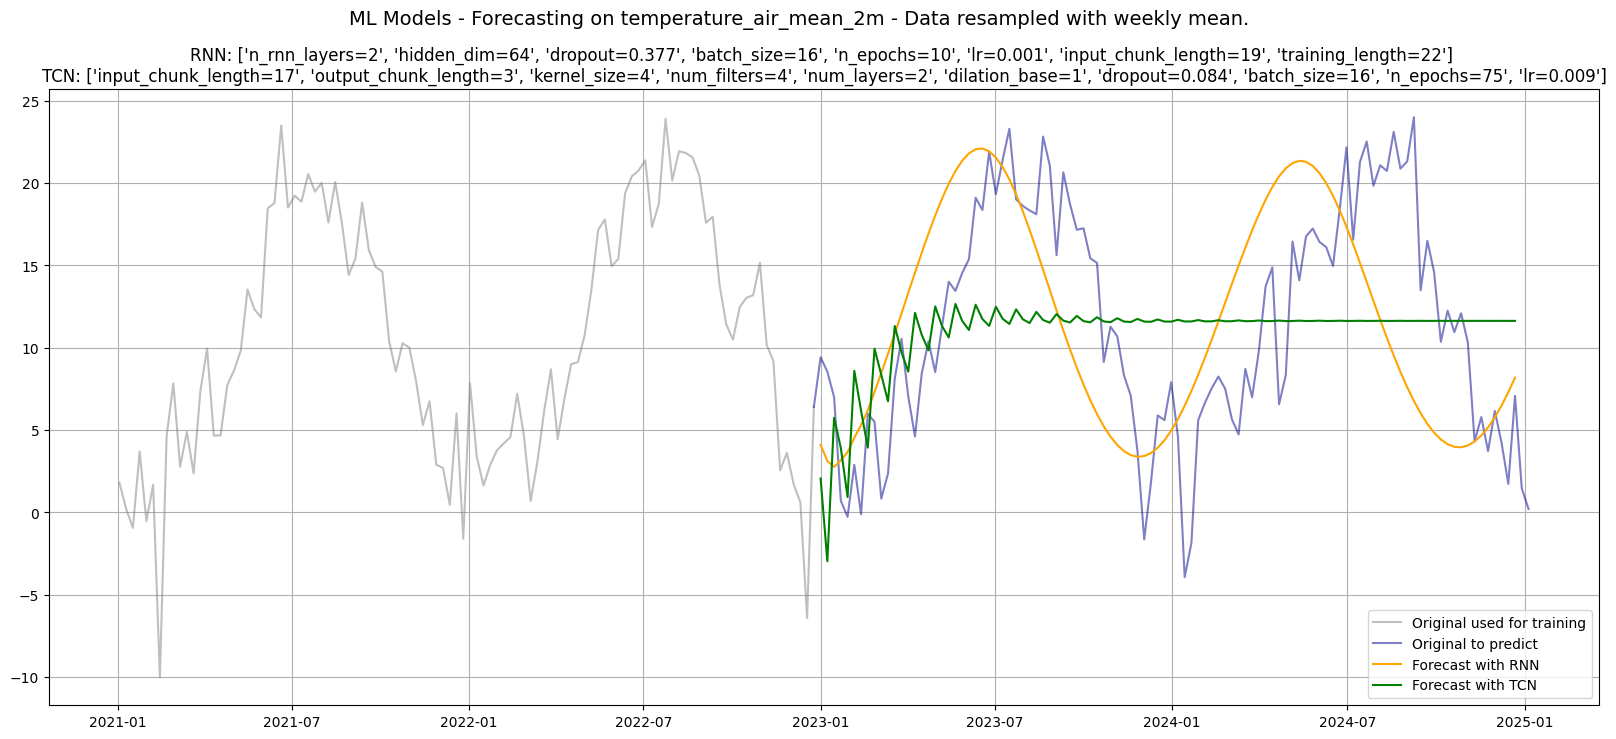

In [51]:
def fmt_params(params):
    return [f"{k}={v:.3f}" if isinstance(v, float) else f"{k}={v}" for k, v in params.items()]

plt.figure(figsize=(20, 8))
plt.plot(df_w_temp.loc["2021":"2022"], label='Original used for training', color='grey', alpha=0.5)
plt.plot(df_w_temp.loc["2022-12-25":], label='Original to predict', color='darkblue', alpha=0.5)
plt.plot(transformer_rnn.inverse_transform(pred_rnn).to_series().loc["2021":],
         label='Forecast with RNN', color='orange')
plt.plot(transformer_tcn.inverse_transform(pred_tcn).to_series().loc["2021":],
         label='Forecast with TCN', color='green')
plt.suptitle(f"ML Models - Forecasting on {df_w_temp.name} - Data resampled with weekly mean.", fontsize=14)
plt.title(f"RNN: {fmt_params(rnn_params)} \nTCN: {fmt_params(tcn_params)}", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()